# Introduction

One of the greatest challenges surrounding machine learning is ensuring that end users can understand as much of the descision making process as possible. Given the nature of most ML problems, we must consider the end user as well as the problem we are attempting to solve in order to improve efficiency but not at the cost of operator skill. 

In this notebook we approach the problem of first break detection in seismic data. Specifically we focus on an approach which is comprehendable to a non ML expert with the goal of generating understanding as well as performance.

---
## Importing code and data
This notebook is a front end to allot of data handling functions that are not user facing they are provided with the notebook and any user with python experience is welcome to dig into them to discover more. Many aspects of the backend functions build upon existing repositories notably Keras.
key to this notebook are the trace objects, which is just a convienient way to hold a set of seismic traces, and bundle them with quick visualisation functions which we'll discuss in turn.

Below there are two options for loading data: 

- One loads a saved instance will all associated results.
- the second imports a specifically formated set of input data


In [ ]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
import colorcet as cc
import pywt
import sklearn.model_selection
%matplotlib inline

from neural_seismic import import_traces, save_exp_instance, mean_residual_calcs
from neural_seismic.models import run_all_models_consis
from neural_seismic.picking import test_coppens, confidence_calcs, convert_series
from neural_seismic.viz import (trace_comparison, plot_scalogram_alt, visualise_classifier,
                                 plot_uncertainty, plot_predictions, plot_violin, plot_viola)
from neural_seismic.utils import notify

---
#### Load results

In [ ]:
# Load saved trace objects from a previous run (dill-serialised .p files are no longer written).
# To reload results, query the results.db inside the experiment output folder:
#
#   import sqlite3, pandas as pd
#   conn = sqlite3.connect('exp_id_<run_id>/results.db')
#   preds = pd.read_sql('SELECT * FROM predictions', conn)
#   history = pd.read_sql('SELECT * FROM training_history', conn)
#
# To query experiment.db for trace metadata and splits:
#   from neural_seismic.db import ExperimentDB
#   with ExperimentDB('experiment.db') as db:
#       df = db.get_predictions('<run_id>')

# Legacy load (only works if old .p files exist):
# test2 = dill.load(open('27122019_1641_Test_TRACES.p', 'rb'))

---
#### Start from Scratch

In [2]:
# Here we import from a specifcally formatted csv. 
comp_trace = import_traces("5000",'Rio')
for trace in comp_trace:
    if pd.Series(trace.FB_Picks[0]).isnull().any():
        trace.FB_Picks[0]=0
    trace.calc_metrics()
    trace.gen_feat_space()

# some of our samples have no first break pick, this will cause issues later so we simply remove them from our analysis for now.
no_zeros=[x for x in comp_trace if x.FB_Picks[1]!=0]
no_zeros=[x for x in no_zeros if x.FB_Picks[0]!=0]
small=no_zeros[:15000]

notify() # this can take some time, so a notification will play when complete

---
## The data
Our dataset has approximately 17,000, each was provided as a raw recording and low pass filtered time series each with 500 data points and a total recording time of 500ms.

In most cases the traces have two interpreted first break picks; one made at the during aquistion, and the other recorded later in the office. Some traces however have no first break pick as such these traces are removed from further analysis.

Below is an example of three traces from our dataset, with the start and end channels trimmed off to emphasise the varied noise components of some signals. Note that the verticle scales are the same for all traces.

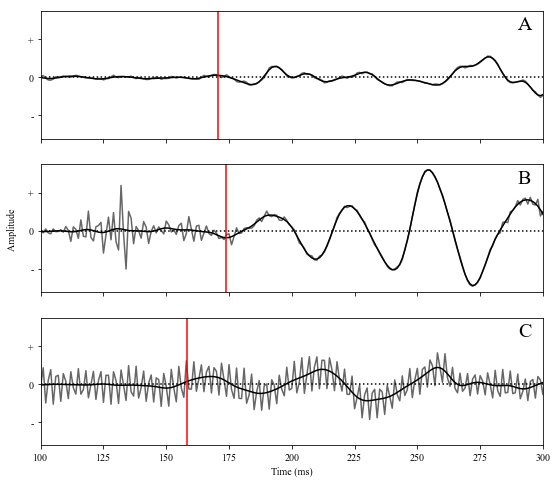

In [4]:
trace_comparison(comp_trace,[103,151,88])

#### Characterising Uncertainty

One of the initial investigations was to evaluate the uncertainty which may exist within our data. For a datset of this scale individual evaluation of every data point is not only time consuming but inconsistent. Instead we forcused on aspects of uncertainty which was represented within the data itself.

There are three uncertainty metrics we considered when first working through this dataset. 
 - Operator disparity: difference between the two interpetor picks, such that higher values are larger differences between the two picking methods.
 - Noise Ratio: Signal to noise ratio such that higher values are greater noise.
 - First Break Analysis : The contrast in amplitudes before and after the first break pick. If there was low contrast then it's a weak refraction and the operator would have more difficulty accurately picking. Such that higher values are lower contrast

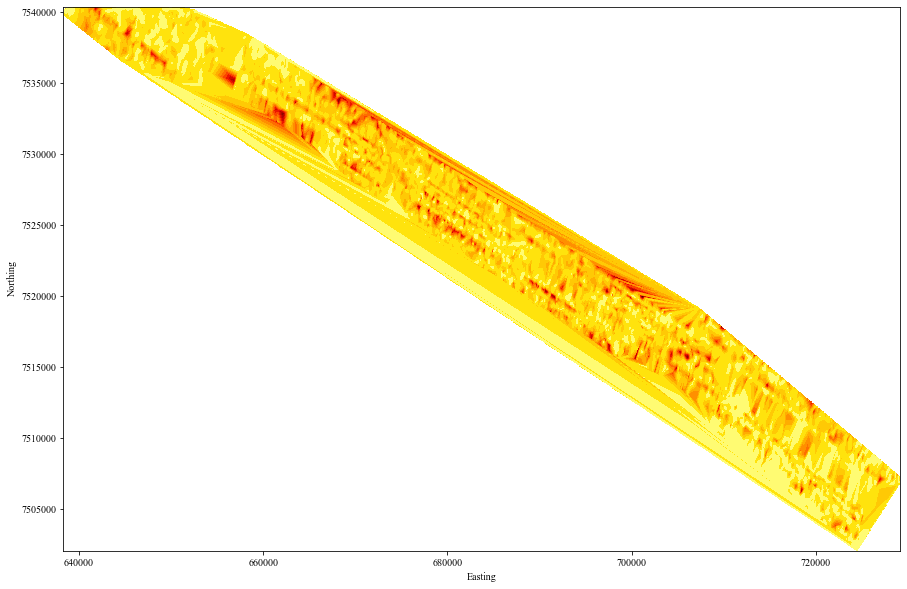

In [4]:
plot_uncertainty(test2,'UM2') # change UM1, UM2, or UM3 to see the differnet methods.

---
### Impact of input space

In addition to developing a methodology that was user comprehendable we wanted to test the impact of inputs on model performance. As such we performed a discrete wavelet analysis over the refraction data. To gain information about how frequencies come and go from the signal could pontentially provided the models with information about where spurious random noise enters and leaves the signal. 

An example scalogram is plotted below which visualises these wavelet co-effients and you can by changing the trace id provide consider the different signals and how they are represented by the scalogram.

In our work we compare between predictions made using only the raw and filtered traces and the raw and filtered traces with this collection of wavelet co-effients.

In [12]:
def plot_scalogram_alt(sel_trace,clr):
    fig, axes = plt.subplots(2,figsize=(9,8), sharex=True,dpi=100,gridspec_kw={'height_ratios': [1,2]})
    trace_i = sel_trace       
    raw = trace_i.Signal_1[0]
    fil = trace_i.Signal_1[1]  
    first_break = trace_i.FB_Picks[1]*1000
    tim = np.linspace(1,500,500)
    sel_trace_iD = trace_i.iD
    
    #performs wavelet transform
    wp = pywt.WaveletPacket(raw, 'db2', 'sym', maxlevel=5)
    nodes = wp.get_level(5, order="freq")
    labels = [n.path for n in nodes]
    values = np.array([n.data for n in nodes], 'd')
    values = abs(values)
    cmap = clr
    
    axes[0].plot(tim,raw,label='Raw',color='k',alpha=0.6)
    axes[0].plot(tim,fil,label='Low-Pass Filter',color='k')
    axes[0].axvline(first_break,label='Interpreted First Break',color='r')
    axes[0].axhline(0,label='Interpreted First Break',color='k',ls=':')
    axes[0].text(460, (max(raw)-max(raw)*0.3), 'A', fontsize=35)
    axes[0].set_yticks([0.00002,0,-0.00002])
    axes[0].set_yticklabels(['+','0','-'])
    axes[0].set_ylabel("Amplitude")
    
    im = plt.imshow(values, interpolation='gaussian', cmap=cmap, aspect="auto", origin="lower", extent=[0, 500, 0, len(values)])
    axes[1].imshow(values, interpolation='gaussian', cmap=cmap, aspect="auto", origin="lower", extent=[0, 500, 0, len(values)])
    axes[1].axvline(first_break,label='Interpreted First Break',color='r')
    plt.colorbar(im,orientation='horizontal')#,cax=f)
    axes[1].set_ylabel('Scale')
    axes[1].text(460, 25, 'B', fontsize=35,color='white')
    
    plt.tight_layout()
    plt.savefig('Figures/Example_Scalogram_iD_'+str(sel_trace_iD)+'.png')
    plt.show()

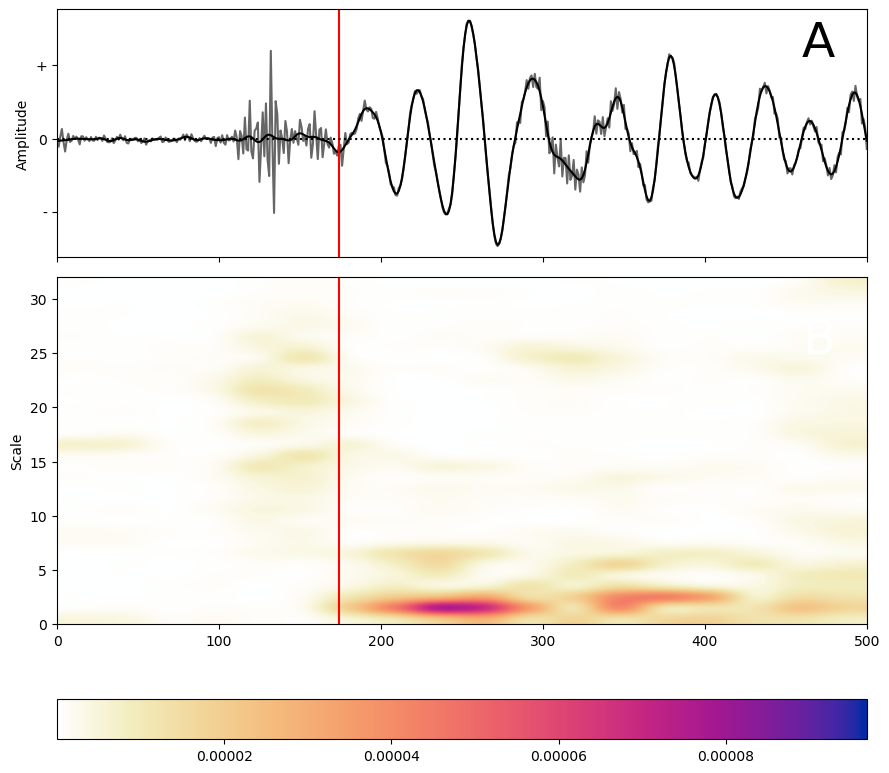

In [17]:
clr_plt = matplotlib.colors.LinearSegmentedColormap.from_list('CET',cc.CET_L17, 256)

plot_scalogram_alt([x for x in test2 if x.iD == 151][0],clr_plt)
#plot_scalogram_alt([x for x in test2 if x.iD == 151][0])

---
## Framing the problem

To make this problem easy to undesrtand we generate a classifier which is execptionally simple. We just create an array of values which change from zero to 1 at the first break we're attempting to replicate. In the figure below we visualise the classifier (green) generated using the first break (blue).

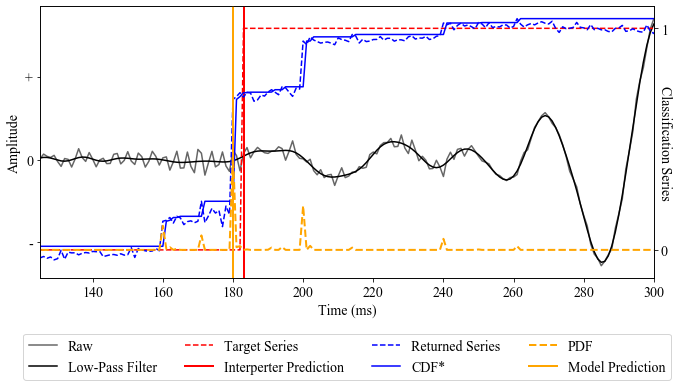

In [28]:
visualise_classifier(test2[6],test2,True)

---
## Splitting Data and implementing Generators
We now understand all the key pre-processing steps for our datset and how we generate our labels. There are some assumtions associated with this process which we'll revisit in a later section. However for now lets move onto howe we divide our data for our models.

The problem we set forth here is ultimately a supervised learning problem. Here we divide our data into a train and test set.
To reduce computational intensity we use what is known as a python generator. For every sample our model must draw in the signal which is our input, (raw, filtered trace with or without the wavelet co-effients) and a target (our classification sequence). The generator simple pulls only the sample it needs at any given time which reduces the cost on memory. This is known as lazy evaluation.

In [6]:
check=[0]
while len(check)<5:
    train, test = sklearn.model_selection.train_test_split(small,train_size=0.6)
    train, vali = sklearn.model_selection.train_test_split(train,train_size=6000)
    check = [x for x in test if x.iD in [88,151,103,2033,4216]] # this check ensures that all our key examples are in our predicted set while keeping random 

---
### Models

This function runs all models described in my text through training on the provided train, test, and vali functions.

The models exact architecture and the generators used to train them are described in the ml_functions.py.

In short the process trains on 100 traces at a time and has validation steps staggered throughout.

The function returns the trained models and all predictions for saving.

The function save_exp_instance() saves all results including coppen's method and returns a modified version of the test set with all predictions and series added to the trace_object.
 
 ---


In [ ]:
models, predictions, histories = run_all_models_consis(train, vali, test)
coppens = test_coppens(test, window=50)

In [ ]:
# Results written to exp_id_<run_id>/results.db and exp_id_<run_id>/<MODEL>_model.p
test_out = save_exp_instance(run_id='notebook_run', test=test, models=models,
                             histories=histories, preds=predictions, coppens=coppens)
notify()

---- 
# Results

Divided into three sections:
 - Mean Prediction Residual calculation
 - Mean Residual Visualsiation
 - Prediction example Visualisation
 - Confidence calculations and visualisation
 
----
#### Mean Prediction Residual

In [7]:
mean_residuals = mean_residual_calcs(test2) # BPNN 01,02,33 | CVNN 01,02,33 | LSTM 01,02,33
mean_residuals

[-134.399,
 -143.43083333333334,
 -122.47366666666667,
 -8.657833333333333,
 -10.989833333333333,
 2.190166666666667,
 21.239833333333333,
 -26.764666666666667,
 -22.271333333333335]

In [4]:
def mse_calcs_onseries(trace_list):
    ''' Uses the prediction series and target series to calculate the mean squared error'''
    
    ksel = ['BPNN01', 'BPNN33', 'CVNN01', 'CVNN33', 'LSTM01', 'LSTM33']
    vals = [[], [], [], [], [], []]
    MSE_dict = dict(zip(ksel,vals))
    
    for trace in trace_list:
        for key in ksel:
            pred_ser = np.array(trace.prediction_series[key])
            targ_ser = np.array(trace.feat_space['Rio_FB'].values)
            error = pred_ser-targ_ser
            error2 = np.square(error)
            SSE = np.sum(error2)
            MSE = SSE/500
            MSE_dict[key].append(MSE)
            
    return(MSE_dict)

def mse_calcs_onpreds(trace_list):
    ''' Uses the prediction series and target series to calculate the mean squared error
    PREDICTED VALUES SHOULD HAVE DIFFERNECE APPLIED THEN MSE ERROR DONE ON ENTIRE ARRAY
    '''
    
    ksel = ['BPNN01', 'BPNN33', 'CVNN01', 'CVNN33', 'LSTM01', 'LSTM33']
    vals = [[], [], [], [], [], []]
    MSE_dict = dict(zip(ksel,vals))
    
    for trace in trace_list:
        for key in ksel:
            pred_val = trace.prediction__value[key]
            targ_val = int(trace.FB_Picks[1]*1000)
            error = pred_val - targ_val
            error2 = np.square(error)
            SSE = np.sum(error2)
            MSE = SSE/2
            MSE_dict[key].append(MSE)
    return(MSE_dict)

In [7]:
MSEval_dict = mse_calcs_onseries(test2)

In [20]:
instance_key = 'LSTM33'

round(np.mean(MSEval_dict[instance_key]),3), np.percentile(MSEval_dict[instance_key], (2.5, 97.5))
# also integrate confidence interval 68 or 95 percentile 
# skewed not normal distributed the quantile is the more appropriate variable

# mean +- standard

(0.092, array([0.00454206, 0.31315639]))

(array([4105., 1175.,  398.,  174.,   80.,   37.,   14.,    7.,    5.,
           5.]),
 array([0.00108317, 0.05166053, 0.1022379 , 0.15281526, 0.20339262,
        0.25396999, 0.30454735, 0.35512471, 0.40570208, 0.45627944,
        0.5068568 ]),
 <a list of 10 Patch objects>)

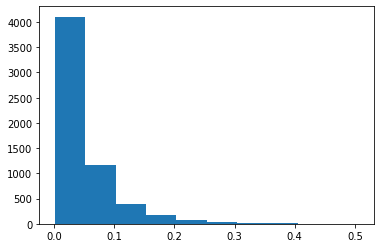

In [100]:
#int(test2[0].FB_Picks[1]*1000)
plt.hist(MSEval_dict['CVNN01'])

In [ ]:
early = [trace.Unc_Metrics[2][0] for trace in test2 if (trace.prediction__value['Coppens'] - int(trace.FB_Picks[1]*1000)) > 0]
late = [trace.Unc_Metrics[2][0] for trace in test2 if (trace.prediction__value['Coppens'] - int(trace.FB_Picks[1]*1000)) < 0]

In [ ]:
(np.nanmean(early),np.nanmean(late))

#### Distribution of Prediction Residuals

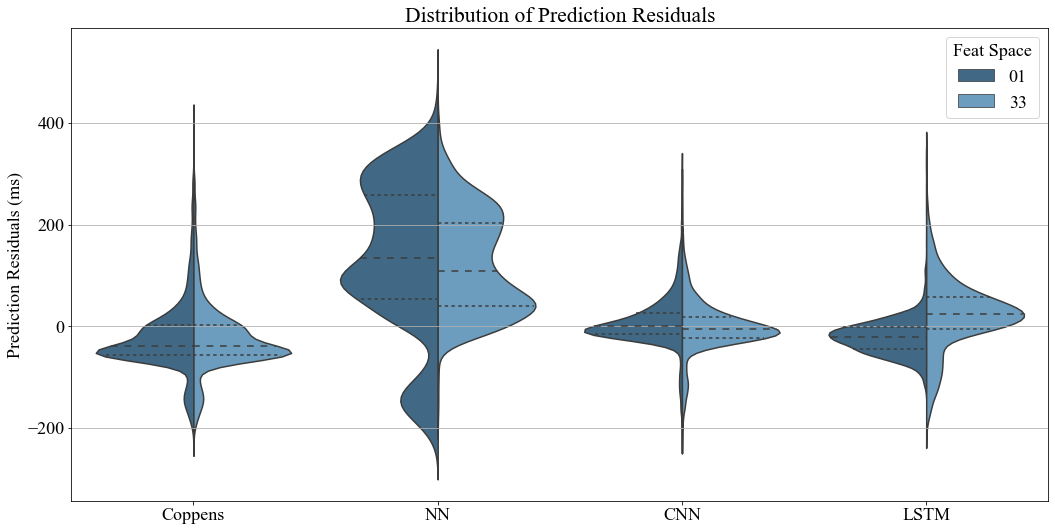

In [10]:
# Generate a long format dataframe and filter it  to the feature spaces we're interested in.
final_df = plot_viola(test2)
filtered = final_df[(final_df["Feat Space"].isin(['01','33']))]

# saves in figures_prediction_residuals.png
plot_violin(filtered) 

---
#### Example Predictions

['Coppens', 'NN01', 'NN33', 'CNN01', 'CNN33', 'LSTM01', 'LSTM33']
['Coppens', 'NN01', 'NN33', 'CNN01', 'CNN33', 'LSTM01', 'LSTM33']
['Coppens', 'NN01', 'NN33', 'CNN01', 'CNN33', 'LSTM01', 'LSTM33']


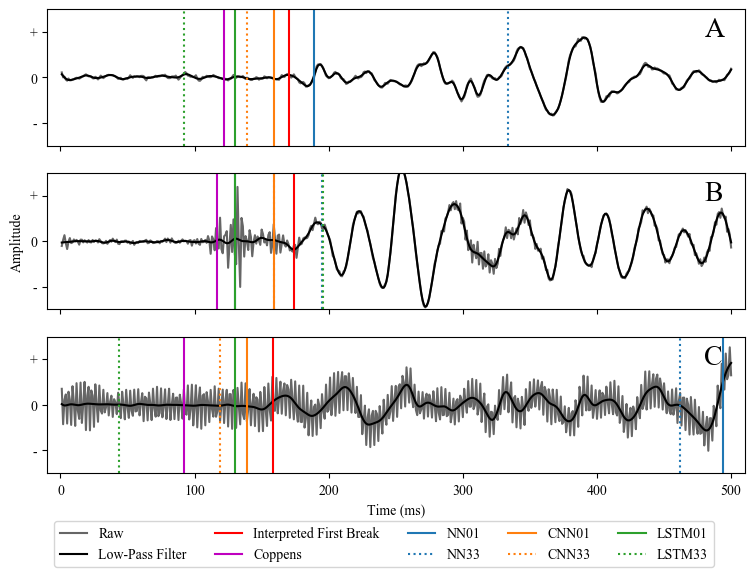

In [165]:
traces_2_plot = [103,151,88]
plot_predictions(traces_2_plot, test2,'Test_A')

['Coppens', 'NN01', 'NN33', 'CNN01', 'CNN33', 'LSTM01', 'LSTM33']
['Coppens', 'NN01', 'NN33', 'CNN01', 'CNN33', 'LSTM01', 'LSTM33']


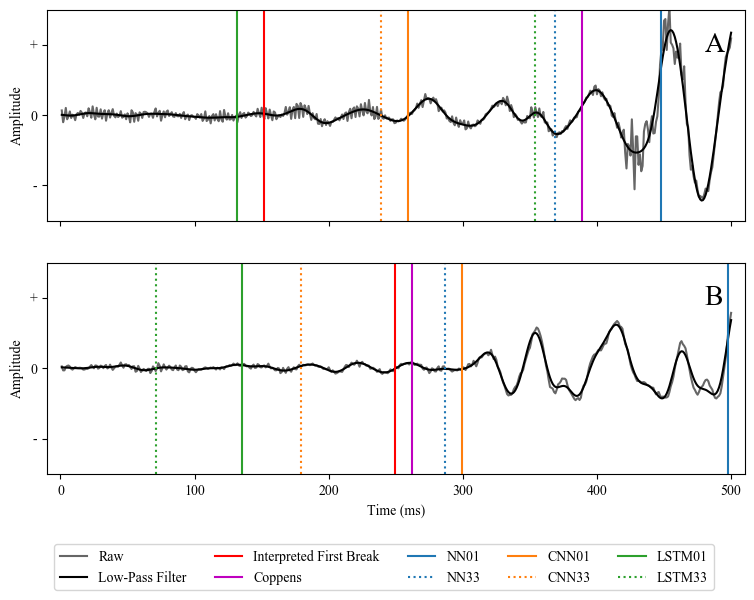

In [166]:
# 12862, 1724
poor_iDs = [9891,4216] # 9891,4216
plot_predictions(poor_iDs,test2,'TESTB')

---
## ACTIVE DEV

In [ ]:
### create an array of prediction series and values for each model converting them in the process
# CVNN

CVNN01_series = [convert_series(x.prediction_series["CVNN01"]) for x in test2]
CVNN01_preds = [x.prediction__value["CVNN01"] for x in test2]
CVNN01_Con = confidence_calcs(CVNN01_preds,CVNN01_series)

#CVNN02_series = [convert_series(x.prediction_series["CVNN02"]) for x in test2]
#CVNN02_preds = [x.prediction__value["CVNN02"] for x in test2]
#CVNN02_Con = confidence_calcs(CVNN02_preds,CVNN02_series)
#
#CVNN33_series = [convert_series(x.prediction_series["CVNN33"]) for x in test2]
#CVNN33_preds = [x.prediction__value["CVNN33"] for x in test2]
#CVNN33_Con = confidence_calcs(CVNN33_preds,CVNN33_series)
#
## LSTM
#LSTM01_series = [convert_series(x.prediction_series["LSTM01"]) for x in test2]
#LSTM01_preds = [x.prediction__value["LSTM01"] for x in test2]
#LSTM01_Con = confidence_calcs(LSTM01_preds,LSTM01_series)
#
#LSTM02_series = [convert_series(x.prediction_series["LSTM02"]) for x in test2]
#LSTM02_preds = [x.prediction__value["LSTM02"] for x in test2]
#LSTM02_Con = confidence_calcs(LSTM02_preds,LSTM02_series)
#
#LSTM33_series = [convert_series(x.prediction_series["LSTM33"]) for x in test2]
#LSTM33_preds = [x.prediction__value["LSTM33"] for x in test2]
#LSTM33_Con = confidence_calcs(LSTM33_preds,LSTM33_series)

In [ ]:
CVNN01_series = #[convert_series(x.prediction_series["CVNN01"])[int((x.FB_Picks[1])*1000)] for x in test2]

In [ ]:
plt.plot(test2[0].prediction_series["CVNN02"],label='CNN')
plt.plot(test2[0].prediction_series["LSTM02"],label='LSTM')
#
plt.plot((test2[0].prediction_series["CVNN02"]),label='CNN')
plt.plot((test2[0].prediction_series["LSTM02"]),label='LSTM')
plt.legend()

In [ ]:
plt.plot(LSTM33_series[0])
#plt.plot(CVNN02_series[0])

In [ ]:
CVNN01_Con_Norm = CVNN01_Con/(max(CVNN01_Con)-min(CVNN01_Con))
CVNN02_Con_Norm = CVNN02_Con/(max(CVNN02_Con)-min(CVNN02_Con))
CVNN33_Con_Norm = CVNN33_Con/(max(CVNN33_Con)-min(CVNN33_Con))

LSTM01_Con_Norm = LSTM01_Con/(max(LSTM01_Con)-min(LSTM01_Con))
LSTM02_Con_Norm = LSTM02_Con/(max(LSTM02_Con)-min(LSTM02_Con))
LSTM33_Con_Norm = LSTM33_Con/(max(LSTM33_Con)-min(LSTM33_Con))

CVNN01_Con_Norm = CVNN01_Con_Norm*100
CVNN02_Con_Norm = CVNN02_Con_Norm*100
CVNN33_Con_Norm = CVNN33_Con_Norm*100
LSTM01_Con_Norm = LSTM01_Con_Norm*100
LSTM02_Con_Norm = LSTM02_Con_Norm*100
LSTM33_Con_Norm = LSTM33_Con_Norm*100

In [ ]:
fig, ax = plt.subplots(2,1,figsize=(10,8))

a=sns.kdeplot(CVNN01_Con_Norm, shade=True,clip=(0,100),label='CVNN-01',ax=ax[0])
b=sns.kdeplot(CVNN02_Con_Norm, shade=True,clip=(0,100),label='CVNN-02',ax=ax[0])
c=sns.kdeplot(CVNN33_Con_Norm, shade=True,clip=(0,100),label='CVNN-33',ax=ax[0])
ax[0].set_xlim(0,100)
ax[0].set_xlabel('Normilised Confidence')
ax[0].set_ylabel('Percent of Predictions')
ax[0].set_yticklabels([int(x) for x in ax[0].get_yticks()*100])

sns.kdeplot(LSTM01_Con_Norm, shade=True,clip=(0,100),label='LSTM-01',ax=ax[1])
sns.kdeplot(LSTM02_Con_Norm, shade=True,clip=(0,100),label='LSTM-02',ax=ax[1])
sns.kdeplot(LSTM33_Con_Norm, shade=True,clip=(0,100),label='LSTM-33',ax=ax[1])
ax[1].set_xlim(0,100)
ax[1].set_xlabel('Normilised Confidence')
ax[1].set_ylabel('Percent of Predictions')
ax[1].set_yticklabels([int(x) for x in ax[1].get_yticks()*100])